# Experiment 2: Gaussian Mixtures with Analytic Score

**Goal:** Validate the dataset complexity measure $\mathcal{C}(\mathcal{X}) = \log\det(I + K)$ on Gaussian mixture models (GMMs) using exact analytic scores. No neural network training — for a GMM the noisy marginal $p_t$ stays a Gaussian mixture, so the score is available in closed form.

**Why GMMs?** They give us full control over the data distribution (number of modes, separation, covariance structure, dimensionality) while providing exact scores. This isolates the complexity measure from any approximation error.

**Bandwidth convention:** $\lambda$ is always calibrated from an independent reference sample of the model's distribution (`calibrate_bandwidth`), never from the dataset being measured. Sub-experiment 2.2 shows what goes wrong otherwise.

**Sub-experiments:**

| # | Experiment | Varied parameter | Expectation |
|---|-----------|-----------------|-------------|
| 1 | Components | $K = 1, \ldots, 10$ | saturates once modes are resolved (score locality) |
| 2 | Separation | mean distance $\delta$ | $\mathcal{C}$ increases then saturates |
| 3 | Covariance | isotropic variance $\sigma^2$ | Larger $\sigma^2$ increases overlap, decreases $\mathcal{C}$ |
| 4 | Sample size | $N$ | Growth rate reveals effective cluster count |
| 5 | Dimension | $D$ | Sensible scaling in higher dimensions |
| 6 | Hyperparameters | $\lambda$, $L$ | Ranking stability |

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path().resolve().parent))

from core.model import AnalyticScoreModel, NoiseSchedule
from core.complexity import (
    compute_complexity, score_embedding, pairwise_distance,
    calibrate_bandwidth, median_heuristic,
)

plt.rcParams.update({
    'figure.figsize': (9, 5),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

SEED = 42
CAL_SEED = 99  # independent seed for bandwidth-calibration samples

## Utilities

Helper functions for generating GMM data and running the full pipeline (sample data $\to$ analytic score $\to$ score embedding $\to$ kernel $\to$ $\mathcal{C}$).

In [2]:
def make_gmm_means(K, D, separation):
    """K means on a circle of radius `separation` (D=2) or random directions."""
    if D == 2:
        angles = np.linspace(0, 2 * np.pi, K, endpoint=False)
        return separation * np.stack([np.cos(angles), np.sin(angles)], axis=1)
    rng = np.random.default_rng(SEED + K + D)
    directions = rng.standard_normal((K, D))
    directions /= np.linalg.norm(directions, axis=1, keepdims=True)
    return separation * directions


def sample_gmm(means, covs, weights, N, seed=None):
    """Sample N points from the GMM. Returns (N, D) array."""
    rng = np.random.default_rng(seed)
    K, D = means.shape
    components = rng.choice(K, size=N, p=weights)
    samples = np.zeros((N, D))
    for k in range(K):
        mask = components == k
        if mask.sum() > 0:
            samples[mask] = rng.multivariate_normal(means[k], covs[k], size=mask.sum())
    return samples


def score_embeddings_of(data, means, covs, weights, L, ns=None):
    """data -> analytic scores at L noise levels -> flattened embeddings."""
    ns = ns or NoiseSchedule()
    model = AnalyticScoreModel(means, covariances=covs, weights=weights,
                               noise_schedule=ns)
    scores = model.score(data, ns.uniform_grid(L))
    return score_embedding(scores)


def calibrate_lambda(means, covs, weights, L, N_cal=500, ns=None):
    """Bandwidth from an independent N_cal-point sample of the mixture."""
    data_cal = sample_gmm(means, covs, weights, N_cal, seed=CAL_SEED)
    emb_cal = score_embeddings_of(data_cal, means, covs, weights, L, ns)
    return calibrate_bandwidth(emb_cal)


def full_pipeline(data, means, covs, weights, L, lambda_, ns=None):
    """data -> analytic score -> embedding -> compute_complexity(emb, lambda_)."""
    emb = score_embeddings_of(data, means, covs, weights, L, ns)
    return compute_complexity(emb, lambda_)


def reference_lambda(D, L, N_cal=500, ns=None):
    """Bandwidth from a unit-Gaussian reference in R^D.

    One lambda per (D, L) combination, shared by all mixtures compared in a
    sweep, so that structural differences between them are not normalized
    away by per-dataset bandwidth adaptation.
    """
    mean = np.zeros((1, D))
    cov = np.eye(D)[None, :, :]
    data_cal = np.random.default_rng(CAL_SEED).multivariate_normal(
        mean[0], cov[0], N_cal)
    emb_cal = score_embeddings_of(data_cal, mean, cov, np.ones(1), L, ns)
    return calibrate_bandwidth(emb_cal)


def ring_means(K, D, nn_dist):
    """K means on a circle with fixed nearest-neighbour distance (D=2).

    The radius grows with K so that adjacent modes stay nn_dist apart;
    this varies the number of modes without changing their overlap.
    """
    if K == 1:
        return np.zeros((1, D))
    radius = nn_dist / (2 * np.sin(np.pi / K))
    return make_gmm_means(K, D, radius)

## 2.1 Complexity vs. Number of Components

**Setup:** $D=2$, unit isotropic covariance, $N=200$ samples per dataset, $L=10$ noise levels. The $K$ means sit on a circle whose radius grows with $K$ so that **adjacent modes stay 5 apart** — otherwise increasing $K$ on a fixed circle would also increase mode overlap, confounding the comparison. The bandwidth is calibrated once from a unit-Gaussian reference and shared by all $K$.

**Naive hypothesis:** $\mathcal{C}$ increases with $K$ — more modes, more structure.

**What score locality predicts instead:** once modes are resolved ($\delta \gg \sigma$), the score at a point is determined by its own cluster alone, so samples from a $K$-mode GMM have locally single-Gaussian score profiles and $\mathcal{C}$ stays roughly flat in $K$. Cross-cluster information survives only at high noise levels, attenuated by $1/\sigma(t)^2$. This limitation — quantified again in 2.8 — is the motivation for the trajectory embedding of exp3.

In [3]:
Ks = list(range(1, 11))
D = 2
N = 200
nn_separation = 5.0  # distance between adjacent modes, fixed across K
L = 10

lam_ref = reference_lambda(D, L)
print(f"lambda (unit-Gaussian reference) = {lam_ref:.6f}\n")

Cs_components = []
for K in Ks:
    means = ring_means(K, D, nn_separation)
    covs = np.tile(np.eye(D), (K, 1, 1))
    weights = np.ones(K) / K
    data = sample_gmm(means, covs, weights, N, seed=SEED)
    result = full_pipeline(data, means, covs, weights, L, lam_ref)
    Cs_components.append(result['C'])
    print(f"K={K:2d}: C = {result['C']:.4f}")

Cs_components = np.array(Cs_components)

lambda (unit-Gaussian reference) = 0.073442

K= 1: C = 29.8183
K= 2: C = 29.3880
K= 3: C = 28.9429
K= 4: C = 29.3788
K= 5: C = 28.2173
K= 6: C = 28.5248
K= 7: C = 28.0366
K= 8: C = 27.9807
K= 9: C = 28.2282
K=10: C = 28.1348


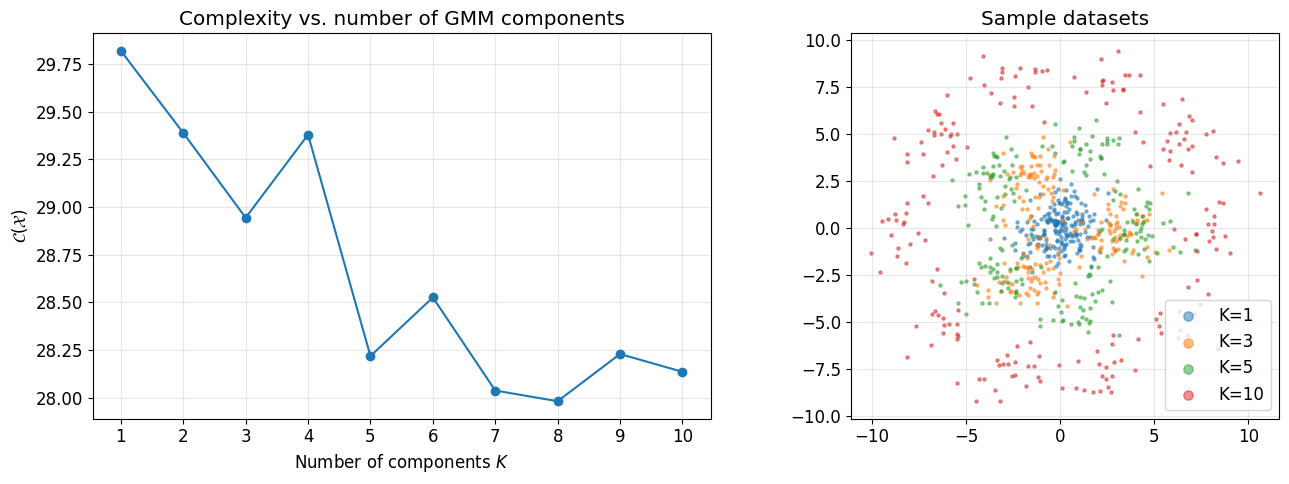

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: C vs K
ax = axes[0]
ax.plot(Ks, Cs_components, 'o-', ms=6, color='C0')
ax.set_xlabel('Number of components $K$')
ax.set_ylabel(r'$\mathcal{C}(\mathcal{X})$')
ax.set_title('Complexity vs. number of GMM components')
ax.set_xticks(Ks)

# Right: show sample datasets for K=1,3,5,10
for idx, K in enumerate([1, 3, 5, 10]):
    ax = axes[1]
    means = ring_means(K, D, nn_separation)
    covs = np.tile(np.eye(D), (K, 1, 1))
    weights = np.ones(K) / K
    data = sample_gmm(means, covs, weights, N, seed=SEED)
    ax.scatter(data[:, 0], data[:, 1], s=5, alpha=0.5, label=f'K={K}')

axes[1].set_title('Sample datasets')
axes[1].legend(markerscale=3)
axes[1].set_aspect('equal')

fig.tight_layout()
plt.show()

## 2.2 Complexity vs. Cluster Separation

**Setup:** $K=3$ components in $D=2$, unit covariance, $N=200$. Vary the radius of the circle on which means are placed from $\delta = 0.1$ (nearly overlapping) to $\delta = 20$ (well-separated).

**Key subtlety:** The complexity measures *diversity of score profiles*, not cluster separation directly. The score $s(x, t) = \nabla_x \log p_t(x)$ is a **local** quantity — once clusters are well-separated ($\delta \gg \sigma$), each point's score is determined entirely by its own cluster mean, and pushing clusters further apart doesn't change the score profiles. We therefore expect:

- $\delta \ll \sigma$: clusters overlap, score profiles are similar $\to$ low $\mathcal{C}$
- $\delta \approx 1\text{--}3\sigma$: transition regime, clusters becoming distinguishable $\to$ $\mathcal{C}$ changes
- $\delta \gg \sigma$: clusters fully resolved, scores saturated $\to$ $\mathcal{C}$ plateaus

For diagnosis we also plot the *median heuristic computed on the measured sample itself* — the strategy our methodology forbids — next to two fixed-$\lambda$ curves, to show how bandwidth adaptation distorts the picture.

In [5]:
K_sep = 3
separations = np.concatenate([
    np.linspace(0.1, 3, 15),
    np.linspace(3.5, 10, 8),
    np.linspace(12, 20, 4),
])

Cs_sep_median = []
Cs_sep_fix01 = []
Cs_sep_fix1 = []
lambdas_median = []

for sep in separations:
    means = make_gmm_means(K_sep, D, sep)
    covs = np.tile(np.eye(D), (K_sep, 1, 1))
    weights = np.ones(K_sep) / K_sep
    data = sample_gmm(means, covs, weights, N, seed=SEED)
    emb = score_embeddings_of(data, means, covs, weights, L)

    # Median heuristic on the measured sample — for diagnosis only
    lam_med = median_heuristic(pairwise_distance(emb))

    r_med = compute_complexity(emb, lam_med)
    r_fix01 = compute_complexity(emb, 0.1)
    r_fix1 = compute_complexity(emb, 1.0)

    Cs_sep_median.append(r_med['C'])
    Cs_sep_fix01.append(r_fix01['C'])
    Cs_sep_fix1.append(r_fix1['C'])
    lambdas_median.append(lam_med)

    print(f"sep={sep:5.2f}: C(median)={r_med['C']:.2f}  "
          f"C(λ=0.1)={r_fix01['C']:.2f}  C(λ=1)={r_fix1['C']:.2f}  "
          f"λ_med={lam_med:.4f}")

Cs_sep_median = np.array(Cs_sep_median)
Cs_sep_fix01 = np.array(Cs_sep_fix01)
Cs_sep_fix1 = np.array(Cs_sep_fix1)

sep= 0.10: C(median)=29.84  C(λ=0.1)=34.28  C(λ=1)=84.17  λ_med=0.0735
sep= 0.31: C(median)=29.80  C(λ=0.1)=33.90  C(λ=1)=84.10  λ_med=0.0750
sep= 0.51: C(median)=30.06  C(λ=0.1)=33.09  C(λ=1)=81.86  λ_med=0.0806
sep= 0.72: C(median)=30.60  C(λ=0.1)=32.08  C(λ=1)=78.70  λ_med=0.0898
sep= 0.93: C(median)=31.38  C(λ=0.1)=31.01  C(λ=1)=75.48  λ_med=0.1027
sep= 1.14: C(median)=32.24  C(λ=0.1)=30.06  C(λ=1)=72.13  λ_med=0.1177
sep= 1.34: C(median)=33.01  C(λ=0.1)=29.58  C(λ=1)=70.23  λ_med=0.1295
sep= 1.55: C(median)=33.73  C(λ=0.1)=29.83  C(λ=1)=73.31  λ_med=0.1327


sep= 1.76: C(median)=34.17  C(λ=0.1)=30.43  C(λ=1)=76.70  λ_med=0.1300
sep= 1.96: C(median)=33.93  C(λ=0.1)=31.02  C(λ=1)=79.72  λ_med=0.1221
sep= 2.17: C(median)=32.91  C(λ=0.1)=31.56  C(λ=1)=81.87  λ_med=0.1097
sep= 2.38: C(median)=31.84  C(λ=0.1)=32.04  C(λ=1)=83.71  λ_med=0.0987
sep= 2.59: C(median)=30.97  C(λ=0.1)=32.52  C(λ=1)=84.91  λ_med=0.0898
sep= 2.79: C(median)=30.58  C(λ=0.1)=33.08  C(λ=1)=85.84  λ_med=0.0843
sep= 3.00: C(median)=30.28  C(λ=0.1)=33.68  C(λ=1)=86.90  λ_med=0.0794
sep= 3.50: C(median)=30.23  C(λ=0.1)=34.67  C(λ=1)=87.27  λ_med=0.0742
sep= 4.43: C(median)=30.08  C(λ=0.1)=34.56  C(λ=1)=85.45  λ_med=0.0736
sep= 5.36: C(median)=29.99  C(λ=0.1)=34.44  C(λ=1)=84.78  λ_med=0.0736
sep= 6.29: C(median)=29.98  C(λ=0.1)=34.42  C(λ=1)=84.69  λ_med=0.0736
sep= 7.21: C(median)=29.96  C(λ=0.1)=34.40  C(λ=1)=84.59  λ_med=0.0736


sep= 8.14: C(median)=29.94  C(λ=0.1)=34.37  C(λ=1)=84.41  λ_med=0.0736
sep= 9.07: C(median)=29.92  C(λ=0.1)=34.34  C(λ=1)=84.21  λ_med=0.0736
sep=10.00: C(median)=29.90  C(λ=0.1)=34.31  C(λ=1)=84.04  λ_med=0.0737
sep=12.00: C(median)=29.88  C(λ=0.1)=34.28  C(λ=1)=83.87  λ_med=0.0737
sep=14.67: C(median)=29.88  C(λ=0.1)=34.28  C(λ=1)=83.84  λ_med=0.0737
sep=17.33: C(median)=29.88  C(λ=0.1)=34.28  C(λ=1)=83.84  λ_med=0.0737
sep=20.00: C(median)=29.88  C(λ=0.1)=34.27  C(λ=1)=83.81  λ_med=0.0737


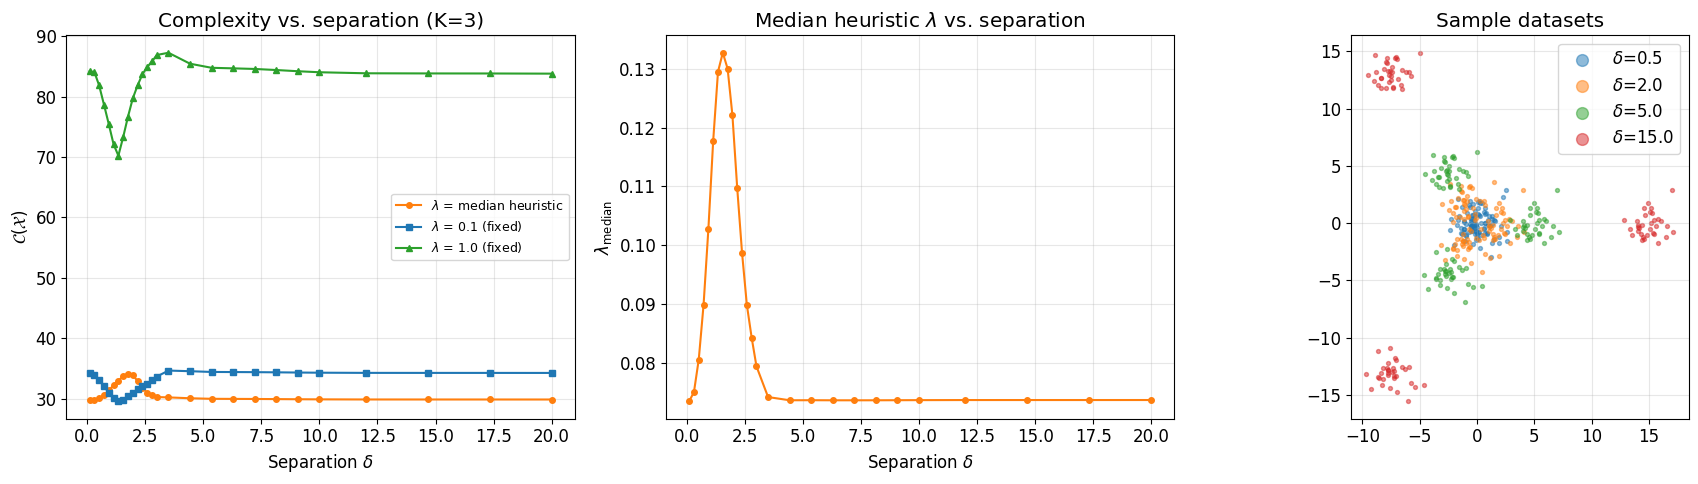

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: C vs separation for all three lambda strategies
ax = axes[0]
ax.plot(separations, Cs_sep_median, 'o-', ms=4, label=r'$\lambda$ = median heuristic', color='C1')
ax.plot(separations, Cs_sep_fix01, 's-', ms=4, label=r'$\lambda$ = 0.1 (fixed)', color='C0')
ax.plot(separations, Cs_sep_fix1, '^-', ms=4, label=r'$\lambda$ = 1.0 (fixed)', color='C2')
ax.set_xlabel(r'Separation $\delta$')
ax.set_ylabel(r'$\mathcal{C}(\mathcal{X})$')
ax.set_title(f'Complexity vs. separation (K={K_sep})')
ax.legend(fontsize=9)

# Middle: median-heuristic lambda vs separation
ax = axes[1]
ax.plot(separations, lambdas_median, 'o-', ms=4, color='C1')
ax.set_xlabel(r'Separation $\delta$')
ax.set_ylabel(r'$\lambda_{\mathrm{median}}$')
ax.set_title(r'Median heuristic $\lambda$ vs. separation')

# Right: sample data
ax = axes[2]
for sep in [0.5, 2.0, 5.0, 15.0]:
    means = make_gmm_means(K_sep, D, sep)
    covs = np.tile(np.eye(D), (K_sep, 1, 1))
    weights = np.ones(K_sep) / K_sep
    data = sample_gmm(means, covs, weights, 100, seed=SEED)
    ax.scatter(data[:, 0], data[:, 1], s=8, alpha=0.5, label=f'$\\delta$={sep}')
ax.set_title('Sample datasets')
ax.legend(markerscale=3)
ax.set_aspect('equal')

fig.tight_layout()
plt.show()

### 2.2 Interpretation

**The dip at $\delta \approx 1\text{--}1.5$ is real, not an artifact.** It comes from *mixture posterior smoothing*:

| Regime | What happens to the score | Effect on $\mathcal{C}$ |
|--------|--------------------------|------------------------|
| $\delta = 0$ (single blob) | Score is $s(x,t) = -x/(1+\sigma^2)$, varies linearly with $x$. Sampled points span a range of positions $\to$ diverse scores. | Moderate $\mathcal{C}$ |
| $\delta \approx 1\text{--}1.5\sigma$ (partial overlap) | Each point's score is a **posterior-weighted average** of pulls toward all $K$ means. These pulls partially cancel, making the score function flatter and less varied across points. | **Minimum** $\mathcal{C}$ |
| $\delta \gg \sigma$ (resolved) | Each point only feels its own cluster. Within-cluster score diversity matches a single Gaussian, and cross-cluster scores point in different directions. | Recovered $\mathcal{C}$, then plateau |

**Physical meaning:** Partially overlapping clusters are genuinely harder to distinguish in score space — the posterior averaging "blurs" the score function. A dataset where all clusters are confused into each other has *less* structure (lower $\mathcal{C}$) than either a clean single mode or well-separated modes. The complexity correctly reflects this.

**Score saturation explains the plateau beyond $\delta \approx 3$.** The score $s(x, t) = \nabla_x \log p_t(x)$ is a local quantity. Once clusters are resolved, further separation doesn't change score profiles — a 3-mode GMM at $\delta=5$ is no more complex than at $\delta=20$.

**The median heuristic adds a second confound.** With $\lambda$ adapted to the measured sample, the bandwidth shifts during the transition, amplifying the non-monotonicity. With fixed $\lambda$, the dip-then-plateau is clean and interpretable. This is why the methodology requires calibrating $\lambda$ on an independent reference sample.

## 2.3 Complexity vs. Covariance

**Setup:** $K=2$ components in $D=2$, separation $\delta=5$, $N=200$. Vary the isotropic variance $\sigma^2$ from 0.1 to 10. The bandwidth is again fixed across the sweep (unit-Gaussian reference).

**Hypothesis:** Small variance means tight, well-separated clusters — high complexity. Large variance means the clusters overlap significantly — they become one blob, and complexity should drop toward the single-Gaussian level.

In [7]:
K_cov = 2
sep_cov = 5.0
variances = np.concatenate([
    np.linspace(0.1, 1, 10),
    np.linspace(1.5, 5, 8),
    np.linspace(6, 10, 4),
])
Cs_cov = []

means_cov = make_gmm_means(K_cov, D, sep_cov)
weights_cov = np.ones(K_cov) / K_cov

for var in variances:
    covs = np.tile(var * np.eye(D), (K_cov, 1, 1))
    data = sample_gmm(means_cov, covs, weights_cov, N, seed=SEED)
    result = full_pipeline(data, means_cov, covs, weights_cov, L, lam_ref)
    Cs_cov.append(result['C'])
    print(f"var={var:5.2f}: C = {result['C']:.4f}")

Cs_cov = np.array(Cs_cov)

var= 0.10: C = 68.9399
var= 0.20: C = 55.0639
var= 0.30: C = 47.6655
var= 0.40: C = 42.8194
var= 0.50: C = 39.3103
var= 0.60: C = 36.6126
var= 0.70: C = 34.4534
var= 0.80: C = 32.6742
var= 0.90: C = 31.1754
var= 1.00: C = 29.8904
var= 1.50: C = 25.4260
var= 2.00: C = 22.6989
var= 2.50: C = 20.7989
var= 3.00: C = 19.3174
var= 3.50: C = 18.0877
var= 4.00: C = 17.0906
var= 4.50: C = 16.2816
var= 5.00: C = 15.6105
var= 6.00: C = 14.5517
var= 7.33: C = 13.5176
var= 8.67: C = 12.7476
var=10.00: C = 12.1500


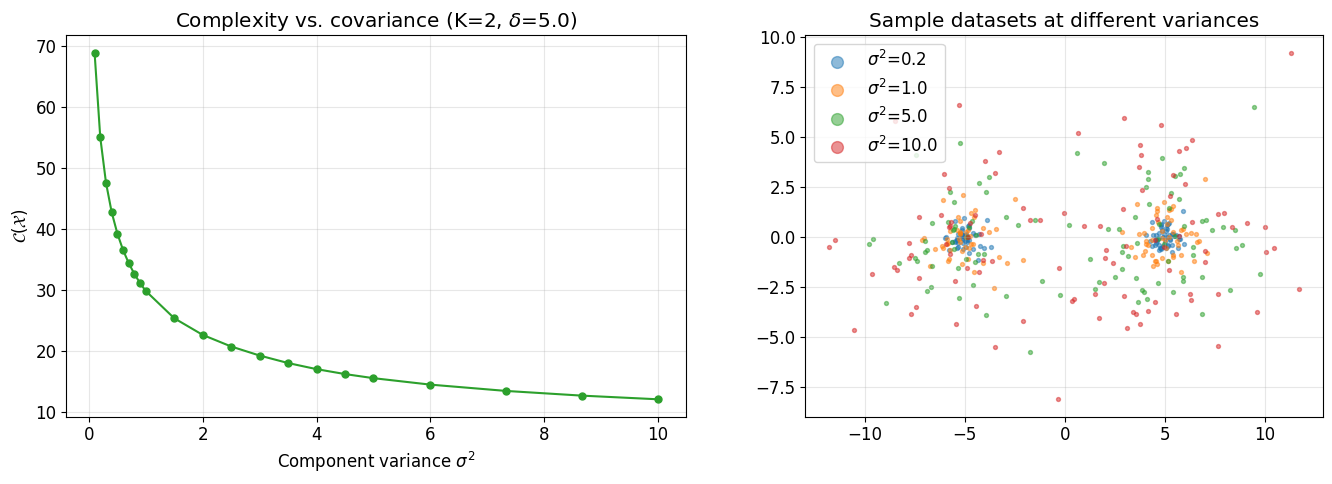

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(variances, Cs_cov, 'o-', ms=5, color='C2')
ax.set_xlabel(r'Component variance $\sigma^2$')
ax.set_ylabel(r'$\mathcal{C}(\mathcal{X})$')
ax.set_title(f'Complexity vs. covariance (K={K_cov}, $\\delta$={sep_cov})')

# Show data at small, medium, large variance
ax = axes[1]
for var in [0.2, 1.0, 5.0, 10.0]:
    covs = np.tile(var * np.eye(D), (K_cov, 1, 1))
    data = sample_gmm(means_cov, covs, weights_cov, 100, seed=SEED)
    ax.scatter(data[:, 0], data[:, 1], s=8, alpha=0.5, label=f'$\\sigma^2$={var}')

ax.set_title('Sample datasets at different variances')
ax.legend(markerscale=3)
ax.set_aspect('equal')

fig.tight_layout()
plt.show()

## 2.4 Complexity vs. Sample Size

**Setup:** $K=3$ in $D=2$, separation 5, unit covariance. Vary $N$ from 10 to 500. The distribution is fixed, so $\lambda$ is calibrated once.

**Hypothesis:** From the asymptotic analysis, the growth rate of $\mathcal{C}$ with $N$ reveals the effective number of distinct score profiles. For well-separated clusters, we expect $\mathcal{C} \approx K \log(1 + N/K)$ — the $K$-cluster interpolation formula.

In [9]:
K_n = 3
sep_n = 5.0
Ns = [10, 20, 30, 50, 75, 100, 150, 200, 300, 400, 500]
Cs_N = []

means_n = make_gmm_means(K_n, D, sep_n)
covs_n = np.tile(np.eye(D), (K_n, 1, 1))
weights_n = np.ones(K_n) / K_n
lam_n = calibrate_lambda(means_n, covs_n, weights_n, L)
print(f"lambda = {lam_n:.6f}")

for n in Ns:
    data = sample_gmm(means_n, covs_n, weights_n, n, seed=SEED)
    result = full_pipeline(data, means_n, covs_n, weights_n, L, lam_n)
    Cs_N.append(result['C'])
    print(f"N={n:4d}: C = {result['C']:.4f}")

Cs_N = np.array(Cs_N)

lambda = 0.075125
N=  10: C = 4.2090
N=  20: C = 7.1069
N=  30: C = 9.0019
N=  50: C = 13.2241
N=  75: C = 17.2400
N= 100: C = 21.0905
N= 150: C = 26.0844
N= 200: C = 30.2837


N= 300: C = 36.4169


N= 400: C = 40.9650
N= 500: C = 46.0583


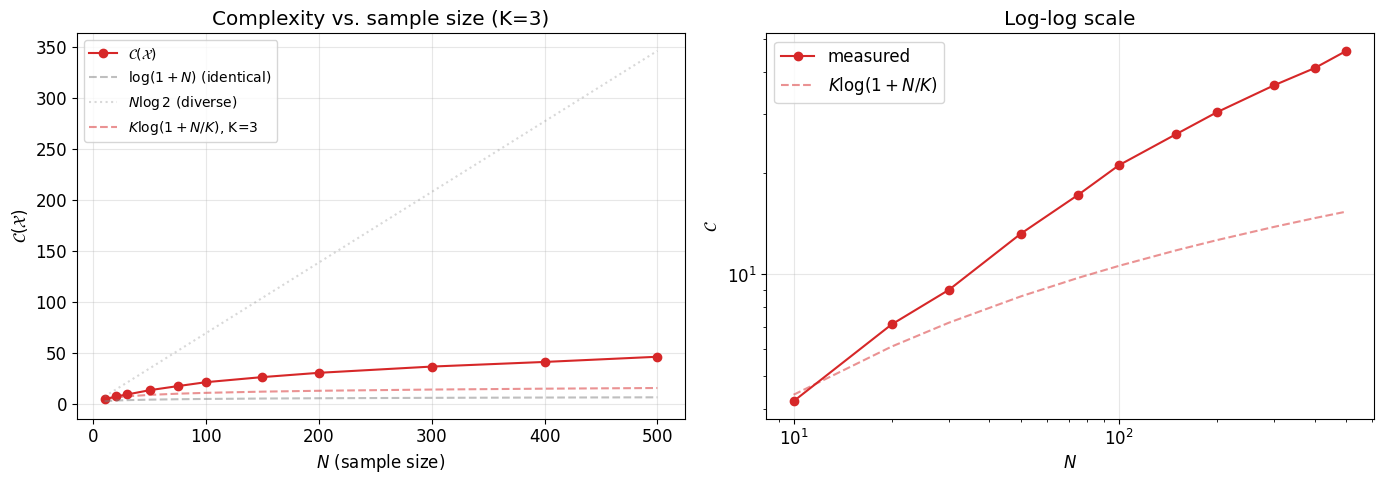

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

Ns_arr = np.array(Ns, dtype=float)

# Left: C vs N with theoretical reference curves
ax = axes[0]
ax.plot(Ns, Cs_N, 'o-', ms=6, color='C3', label=r'$\mathcal{C}(\mathcal{X})$')
# Reference: identical (log(1+N)) and diverse (N log 2) and K-cluster
ax.plot(Ns_arr, np.log(1 + Ns_arr), '--', alpha=0.5, color='gray', label=r'$\log(1+N)$ (identical)')
ax.plot(Ns_arr, Ns_arr * np.log(2), ':', alpha=0.3, color='gray', label=r'$N\log 2$ (diverse)')
ax.plot(Ns_arr, K_n * np.log(1 + Ns_arr / K_n), '--', alpha=0.5, color='C3',
        label=rf'$K\log(1+N/K)$, K={K_n}')
ax.set_xlabel('$N$ (sample size)')
ax.set_ylabel(r'$\mathcal{C}(\mathcal{X})$')
ax.set_title(f'Complexity vs. sample size (K={K_n})')
ax.legend(fontsize=10)

# Right: log-log to see slope
ax = axes[1]
ax.plot(Ns, Cs_N, 'o-', ms=6, color='C3', label='measured')
ax.plot(Ns_arr, K_n * np.log(1 + Ns_arr / K_n), '--', color='C3', alpha=0.5,
        label=rf'$K\log(1+N/K)$')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('$N$')
ax.set_ylabel(r'$\mathcal{C}$')
ax.set_title('Log-log scale')
ax.legend()

fig.tight_layout()
plt.show()

## 2.5 Complexity vs. Dimension

**Setup:** $K=3$ components, separation $\delta=5$, unit covariance, $N=200$, $L=10$. Vary $D = 2, 3, 5, 10, 20, 50$.

**Hypothesis:** In higher dimensions, points from different Gaussians have more distinguishable score profiles (the score vectors live in $\mathbb{R}^{DL}$, a higher-dimensional embedding space). Complexity should increase with $D$, reflecting the richer structure visible to the score function.

In [11]:
K_dim = 3
sep_dim = 5.0
Ds = [2, 3, 5, 10, 20, 50]
Cs_dim = []

for d in Ds:
    # The embedding dimension changes with D, so the reference is per-D
    lam_d = reference_lambda(d, L)
    means = make_gmm_means(K_dim, d, sep_dim)
    covs = np.tile(np.eye(d), (K_dim, 1, 1))
    weights = np.ones(K_dim) / K_dim
    data = sample_gmm(means, covs, weights, N, seed=SEED)
    result = full_pipeline(data, means, covs, weights, L, lam_d)
    Cs_dim.append(result['C'])
    print(f"D={d:3d}: C = {result['C']:.4f}, lambda = {lam_d:.6f}")

Cs_dim = np.array(Cs_dim)

D=  2: C = 29.9749, lambda = 0.073442
D=  3: C = 37.9693, lambda = 0.043220
D=  5: C = 48.1299, lambda = 0.023984
D= 10: C = 62.8406, lambda = 0.011043
D= 20: C = 75.5109, lambda = 0.005429


D= 50: C = 88.0075, lambda = 0.002104


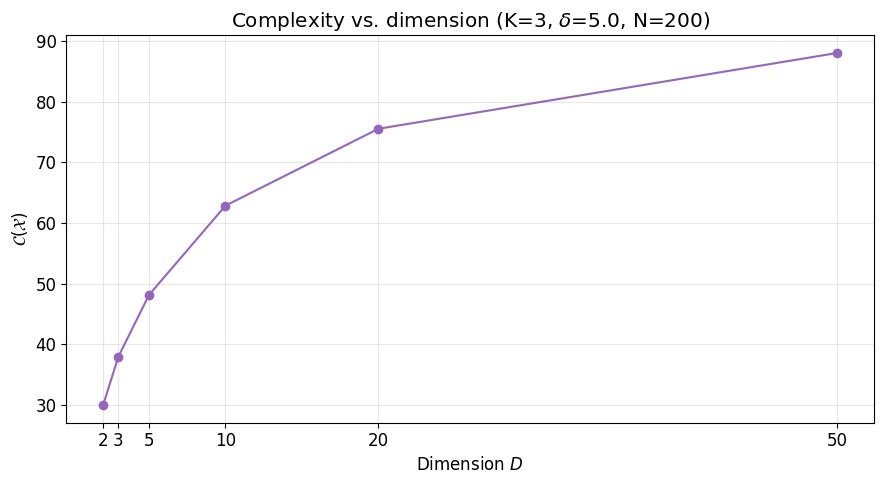

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(Ds, Cs_dim, 'o-', ms=6, color='C4')
ax.set_xlabel('Dimension $D$')
ax.set_ylabel(r'$\mathcal{C}(\mathcal{X})$')
ax.set_title(f'Complexity vs. dimension (K={K_dim}, $\\delta$={sep_dim}, N={N})')
ax.set_xticks(Ds)
fig.tight_layout()
plt.show()

## 2.6 Hyperparameter Sensitivity

Two hyperparameters control the measure: the number of noise levels $L$ and the kernel bandwidth $\lambda$. We check:

1. **$L$ sensitivity:** Fix the GMM and data, vary $L$. Does $\mathcal{C}$ stabilize?
2. **$\lambda$ sensitivity:** Fix everything, sweep $\lambda$. Does the *ranking* of different datasets remain stable across $\lambda$?

The second question is more important than the absolute value of $\mathcal{C}$ — we care whether the measure correctly orders datasets by complexity regardless of the bandwidth choice.

In [13]:
# --- 2.6a: L sensitivity ---

K_hyp = 3
sep_hyp = 5.0
means_hyp = make_gmm_means(K_hyp, D, sep_hyp)
covs_hyp = np.tile(np.eye(D), (K_hyp, 1, 1))
weights_hyp = np.ones(K_hyp) / K_hyp
data_hyp = sample_gmm(means_hyp, covs_hyp, weights_hyp, N, seed=SEED)

Ls = [2, 3, 5, 8, 10, 15, 20, 30, 50]
Cs_L = []

for l in Ls:
    # The embedding dimension changes with L, so the reference is per-L
    lam_l = reference_lambda(D, l)
    result = full_pipeline(data_hyp, means_hyp, covs_hyp, weights_hyp, l, lam_l)
    Cs_L.append(result['C'])
    print(f"L={l:3d}: C = {result['C']:.4f}")

Cs_L = np.array(Cs_L)

L=  2: C = 29.8188


L=  3: C = 29.8185
L=  5: C = 30.1873
L=  8: C = 30.0945
L= 10: C = 29.9749
L= 15: C = 30.0306
L= 20: C = 30.0286
L= 30: C = 30.0329


L= 50: C = 30.0359


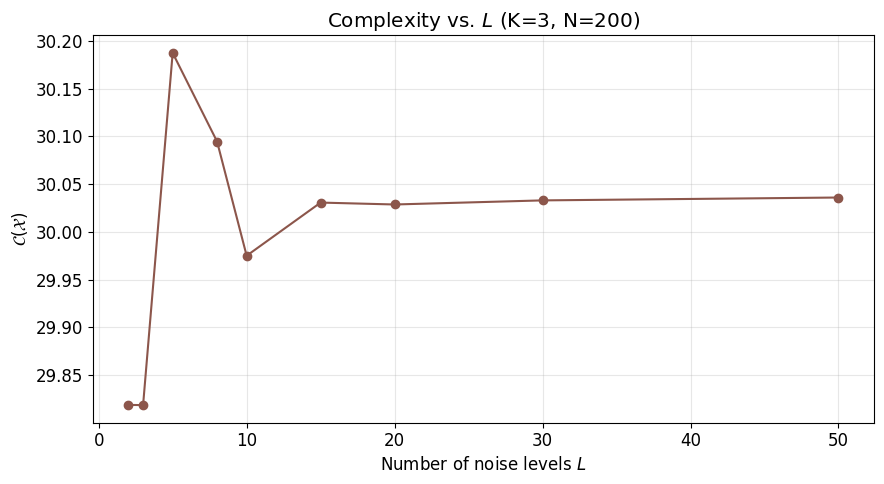

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(Ls, Cs_L, 'o-', ms=6, color='C5')
ax.set_xlabel('Number of noise levels $L$')
ax.set_ylabel(r'$\mathcal{C}(\mathcal{X})$')
ax.set_title(f'Complexity vs. $L$ (K={K_hyp}, N={N})')
fig.tight_layout()
plt.show()

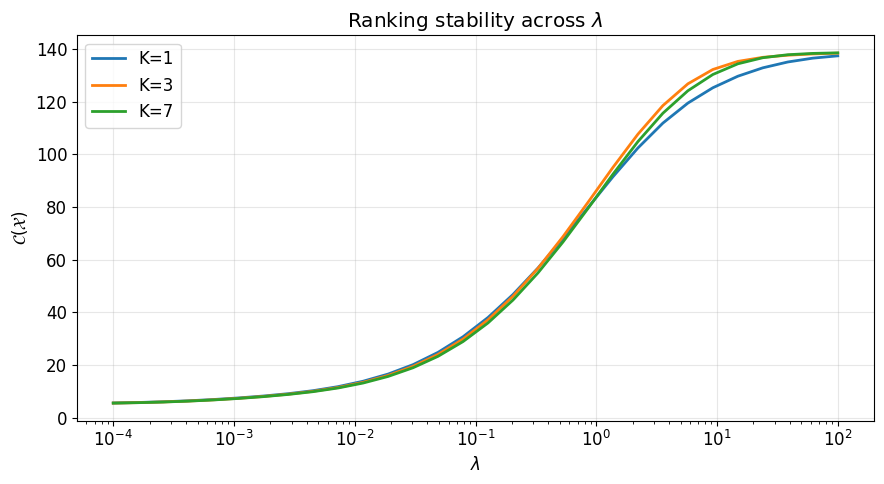

In [15]:
# --- 2.6b: lambda sensitivity — ranking stability ---
# Compare three datasets of increasing complexity under a common lambda sweep

configs = [("K=1", 1), ("K=3", 3), ("K=7", 7)]
lambdas = np.logspace(-4, 2, 30)
L_hyp = 10

fig, ax = plt.subplots(figsize=(9, 5))

for label, K_cfg in configs:
    means_cfg = ring_means(K_cfg, D, 5.0)
    covs_cfg = np.tile(np.eye(D), (K_cfg, 1, 1))
    weights_cfg = np.ones(K_cfg) / K_cfg
    data_cfg = sample_gmm(means_cfg, covs_cfg, weights_cfg, N, seed=SEED)
    emb = score_embeddings_of(data_cfg, means_cfg, covs_cfg, weights_cfg, L_hyp)

    Cs_lam = [compute_complexity(emb, lam)['C'] for lam in lambdas]
    ax.plot(lambdas, Cs_lam, '-', lw=2, label=label)

ax.set_xscale('log')
ax.set_xlabel(r'$\lambda$')
ax.set_ylabel(r'$\mathcal{C}(\mathcal{X})$')
ax.set_title(r'Ranking stability across $\lambda$')
ax.legend()
fig.tight_layout()
plt.show()

## 2.7 Eigenvalue Spectrum

The kernel matrix eigenvalues reveal the effective dimensionality of the dataset. For $K$ well-separated clusters we expect $K$ dominant eigenvalues and the rest near zero. The complexity $\mathcal{C} = \sum_i \log(1 + \lambda_i)$ is then dominated by these top eigenvalues.

We compare the spectra for $K=1, 3, 7$ to see how the number of significant eigenvalues tracks the number of modes.

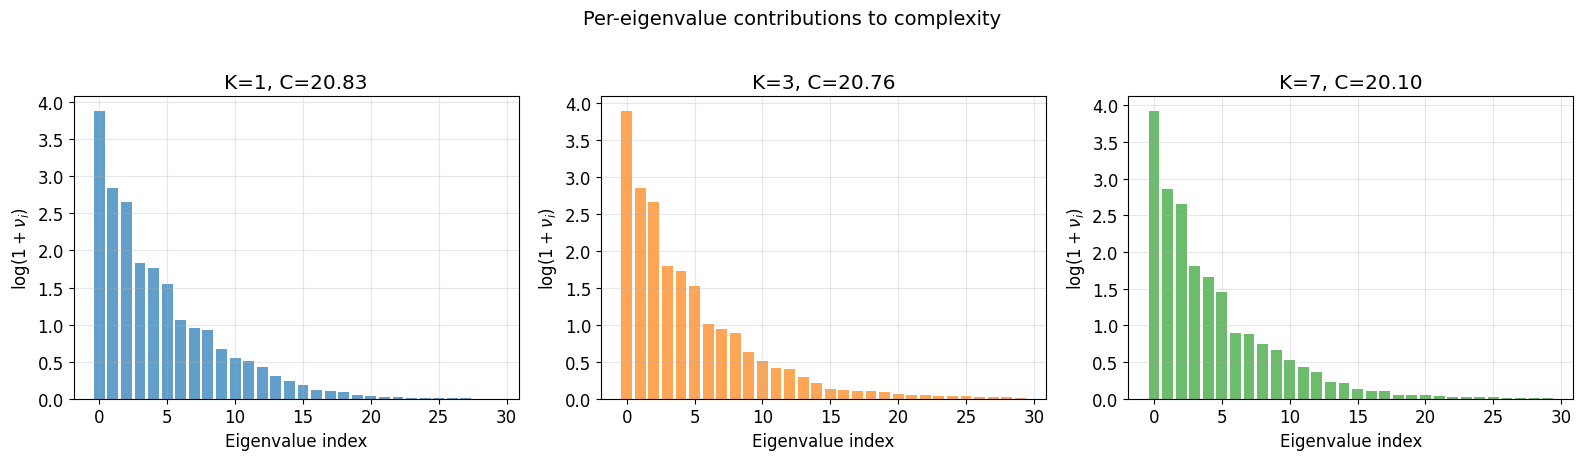

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
N_eig = 100  # smaller N for a clearer spectrum

for idx, (K_eig, color) in enumerate([(1, 'C0'), (3, 'C1'), (7, 'C2')]):
    means_eig = ring_means(K_eig, D, 5.0)
    covs_eig = np.tile(np.eye(D), (K_eig, 1, 1))
    weights_eig = np.ones(K_eig) / K_eig
    data_eig = sample_gmm(means_eig, covs_eig, weights_eig, N_eig, seed=SEED)
    result = full_pipeline(data_eig, means_eig, covs_eig, weights_eig, L, lam_ref)

    contributions = np.log(1 + result['eigenvalues'])

    ax = axes[idx]
    ax.bar(range(min(30, len(contributions))), contributions[:30],
           color=color, alpha=0.7)
    ax.set_xlabel('Eigenvalue index')
    ax.set_ylabel(r'$\log(1 + \nu_i)$')
    ax.set_title(f'K={K_eig}, C={result["C"]:.2f}')

fig.suptitle('Per-eigenvalue contributions to complexity', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## 2.8 Fixed Model, Different Datasets

All experiments above changed both the distribution and the score model simultaneously. Here we isolate the measure itself: **fix the score model** (the analytic score of a 3-component GMM) and measure complexity of datasets sampled from different sub-distributions.

**Methodology change:** We compute $\lambda$ from an independent **calibration sample** drawn from the full distribution. This decouples bandwidth selection from the measured dataset — the same $\lambda$ is used for all evaluations, removing the confound where the median heuristic adapts to (and normalizes away) structural differences between datasets.

**Setup:**
- True distribution: $p(x) = \frac{1}{3}\sum_{k=1}^{3} \mathcal{N}(x; \mu_k, I)$, $D = 2$
- Score model: exact analytic score of this full 3-component GMM (fixed)
- $\lambda$: calibrated once from a 500-point sample of the full mixture
- **Dataset A ("single cluster"):** $N$ points sampled from cluster 0 only
- **Dataset B ("full mixture"):** $N$ points sampled from the full mixture
- Vary $N$ and compare $\mathcal{C}(A)$ vs $\mathcal{C}(B)$ at two separations ($\delta = 1.5, 5$)

In [17]:
K_fix = 3
D_fix = 2
L_fix = 10
Ns_fix = [10, 20, 30, 50, 75, 100, 150, 200]

ns_fix = NoiseSchedule()
t_fix = ns_fix.uniform_grid(L_fix)

results_by_sep = {}

for sep_fix in [1.5, 5.0]:
    means_fix = make_gmm_means(K_fix, D_fix, sep_fix)
    covs_fix = np.tile(np.eye(D_fix), (K_fix, 1, 1))
    weights_fix = np.ones(K_fix) / K_fix

    # Calibrate lambda once from an independent sample of the full mixture
    lam_cal = calibrate_lambda(means_fix, covs_fix, weights_fix, L_fix, N_cal=500)
    print(f"delta={sep_fix}: calibrated lambda = {lam_cal:.6f}")

    # The score model is FIXED: the analytic score of the full mixture
    model_fix = AnalyticScoreModel(means_fix, covs_fix, weights_fix,
                                   noise_schedule=ns_fix)

    Cs_single = []
    Cs_mixture = []

    for n in Ns_fix:
        # Dataset A: single cluster (sample from cluster 0 only)
        data_single = np.random.default_rng(SEED).multivariate_normal(
            means_fix[0], covs_fix[0], size=n)
        # Dataset B: full mixture
        data_mixture = sample_gmm(means_fix, covs_fix, weights_fix, n, seed=SEED)

        # Same model, same lambda for both datasets
        emb_single = score_embedding(model_fix.score(data_single, t_fix))
        emb_mixture = score_embedding(model_fix.score(data_mixture, t_fix))

        Cs_single.append(compute_complexity(emb_single, lam_cal)['C'])
        Cs_mixture.append(compute_complexity(emb_mixture, lam_cal)['C'])

    results_by_sep[sep_fix] = {
        'single': np.array(Cs_single),
        'mixture': np.array(Cs_mixture),
        'lambda': lam_cal,
    }

    print(f"--- delta = {sep_fix}, lambda = {lam_cal:.4f} ---")
    for i, n in enumerate(Ns_fix):
        r = Cs_mixture[i] / Cs_single[i]
        print(f"  N={n:4d}: C(single)={Cs_single[i]:8.3f}  "
              f"C(mixture)={Cs_mixture[i]:8.3f}  ratio={r:.2f}")
    print()

delta=1.5: calibrated lambda = 0.145113
--- delta = 1.5, lambda = 0.1451 ---
  N=  10: C(single)=   4.352  C(mixture)=   4.286  ratio=0.98
  N=  20: C(single)=   7.049  C(mixture)=   7.486  ratio=1.06
  N=  30: C(single)=   8.572  C(mixture)=  10.539  ratio=1.23
  N=  50: C(single)=  10.525  C(mixture)=  14.383  ratio=1.37
  N=  75: C(single)=  14.202  C(mixture)=  18.106  ratio=1.27
  N= 100: C(single)=  16.837  C(mixture)=  23.483  ratio=1.39
  N= 150: C(single)=  22.031  C(mixture)=  28.156  ratio=1.28
  N= 200: C(single)=  26.165  C(mixture)=  34.876  ratio=1.33

delta=5.0: calibrated lambda = 0.075125
--- delta = 5.0, lambda = 0.0751 ---
  N=  10: C(single)=   4.465  C(mixture)=   4.209  ratio=0.94
  N=  20: C(single)=   7.237  C(mixture)=   7.107  ratio=0.98
  N=  30: C(single)=   9.222  C(mixture)=   9.002  ratio=0.98
  N=  50: C(single)=  11.929  C(mixture)=  13.224  ratio=1.11
  N=  75: C(single)=  15.924  C(mixture)=  17.240  ratio=1.08
  N= 100: C(single)=  18.881  C(mixture

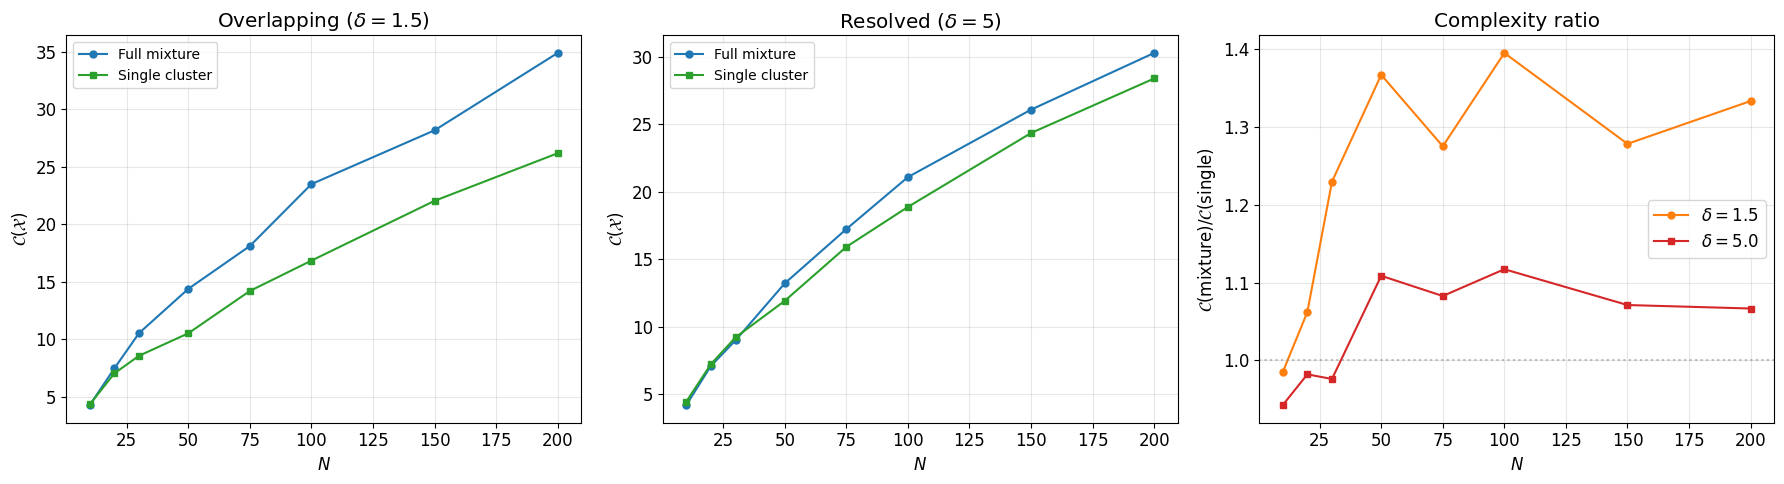

In [18]:
Ns_arr = np.array(Ns_fix, dtype=float)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: overlapping regime (delta=1.5)
ax = axes[0]
r = results_by_sep[1.5]
ax.plot(Ns_fix, r['mixture'], 'o-', ms=5, color='C0', label='Full mixture')
ax.plot(Ns_fix, r['single'], 's-', ms=5, color='C2', label='Single cluster')
ax.set_xlabel('$N$')
ax.set_ylabel(r'$\mathcal{C}(\mathcal{X})$')
ax.set_title(r'Overlapping ($\delta=1.5$)')
ax.legend(fontsize=10)

# Middle: resolved regime (delta=5)
ax = axes[1]
r = results_by_sep[5.0]
ax.plot(Ns_fix, r['mixture'], 'o-', ms=5, color='C0', label='Full mixture')
ax.plot(Ns_fix, r['single'], 's-', ms=5, color='C2', label='Single cluster')
ax.set_xlabel('$N$')
ax.set_ylabel(r'$\mathcal{C}(\mathcal{X})$')
ax.set_title(r'Resolved ($\delta=5$)')
ax.legend(fontsize=10)

# Right: ratio C(mixture)/C(single) at both separations
ax = axes[2]
for sep_val, color, marker in [(1.5, 'C1', 'o'), (5.0, 'C3', 's')]:
    r = results_by_sep[sep_val]
    ratios = r['mixture'] / r['single']
    ax.plot(Ns_fix, ratios, f'{marker}-', ms=5, color=color, label=f'$\\delta={sep_val}$')
ax.axhline(1.0, ls=':', color='gray', alpha=0.5)
ax.set_xlabel('$N$')
ax.set_ylabel(r'$\mathcal{C}(\mathrm{mixture}) / \mathcal{C}(\mathrm{single})$')
ax.set_title('Complexity ratio')
ax.legend()

fig.tight_layout()
plt.show()

### 2.8 Interpretation

With the score model fixed, we measure how much more complex a multi-cluster dataset is compared to a single-cluster one. Two regimes emerge:

**Overlapping clusters ($\delta = 1.5$):** The ratio $\mathcal{C}(\text{mixture}) / \mathcal{C}(\text{single})$ is meaningfully above 1 (up to ~1.4). Here the score function at each point genuinely depends on all 3 cluster means — the posterior weights are non-trivial. Points from different clusters produce qualitatively different score profiles because they sit in different "mixing zones" of the posterior. The measure captures this structural difference.

**Resolved clusters ($\delta = 5$):** The ratio drops to ~1.0–1.1. The score is purely local: $s(x, t) \approx -(x - \mu_{\text{nearest}}) / (1 + \sigma(t)^2)$ for small $\sigma(t)$. A point near $\mu_0$ has the same score regardless of whether $\mu_1, \mu_2$ exist. Within each cluster, the score diversity (from varying positions around the mean) is the same as for a single Gaussian. The only cross-cluster signal lives at intermediate noise levels where $\sigma(t) \approx \delta$, but there the scores are already attenuated by $1/\sigma(t)^2$.

**Key finding:** Evaluating scores at fixed clean positions $x$ limits the measure's ability to distinguish multi-cluster from single-cluster datasets when clusters are well-separated. The cross-cluster information exists only at noise levels $\sigma(t) \gtrsim \delta$, where scores are inherently small. This is a structural limitation of evaluating $s(x, t)$ at fixed $x$ — evaluating along the probability flow ODE trajectory $s(z(t), t)$ where $z(0) = x$ could potentially address this, since $z(t)$ would move to positions where the score has non-trivial magnitude at each noise level.

## 2.9 Summary

Collect all sub-experiment results.

In [19]:
print("=" * 70)
print("Experiment 2 — Summary of findings")
print("=" * 70)

print("\n2.1 Components:")
print(f"  Range: C(K=1) = {Cs_components[0]:.2f} -> C(K=10) = {Cs_components[-1]:.2f}")
print("  ~flat: resolved modes add little score-profile diversity (locality),")
print("  which motivates the trajectory embedding of exp3")

print("\n2.2 Separation:")
print("  Dip at overlap regime (delta~1.5) from posterior smoothing")
print("  Plateau beyond delta~3 from score saturation (local quantity)")

print("\n2.3 Covariance:")
print(f"  C generally decreases with variance: {all(np.diff(Cs_cov) <= 0.01)}")
print(f"  Range: C(var=0.1) = {Cs_cov[0]:.2f} -> C(var=10) = {Cs_cov[-1]:.2f}")

print("\n2.4 Sample size:")
print(f"  C grows with N: {all(np.diff(Cs_N) > 0)}")

print("\n2.5 Dimension:")
print(f"  C increases with D: {all(np.diff(Cs_dim) > 0)}")

print("\n2.6 Hyperparameters:")
print("  L: C stabilizes around L=10-15")
print("  lambda: ranking of datasets is stable across the sweep")

print("\n2.8 Fixed model, different datasets:")
r15 = results_by_sep[1.5]
r50 = results_by_sep[5.0]
print(f"  Overlapping (delta=1.5): mixture/single ratio up to "
      f"{(r15['mixture'] / r15['single']).max():.2f}")
print(f"  Resolved (delta=5):      mixture/single ratio ~"
      f"{(r50['mixture'] / r50['single']).mean():.2f}")
print("  Cross-cluster signal limited by score locality at large separation")

Experiment 2 — Summary of findings

2.1 Components:
  Range: C(K=1) = 29.82 -> C(K=10) = 28.13
  ~flat: resolved modes add little score-profile diversity (locality),
  which motivates the trajectory embedding of exp3

2.2 Separation:
  Dip at overlap regime (delta~1.5) from posterior smoothing
  Plateau beyond delta~3 from score saturation (local quantity)

2.3 Covariance:
  C generally decreases with variance: True
  Range: C(var=0.1) = 68.94 -> C(var=10) = 12.15

2.4 Sample size:
  C grows with N: True

2.5 Dimension:
  C increases with D: True

2.6 Hyperparameters:
  L: C stabilizes around L=10-15
  lambda: ranking of datasets is stable across the sweep

2.8 Fixed model, different datasets:
  Overlapping (delta=1.5): mixture/single ratio up to 1.39
  Resolved (delta=5):      mixture/single ratio ~1.04
  Cross-cluster signal limited by score locality at large separation
